In [12]:
!pip install torchvision
!pip install numpy
!pip install matplotlib
!pip install opencv-python

In [13]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torchvision
import torch


In [14]:
# Definir o pré processamento de dados
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224),
    ])

# Carregar o conjunto de treino
train_data = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
    )

test_data = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
    )

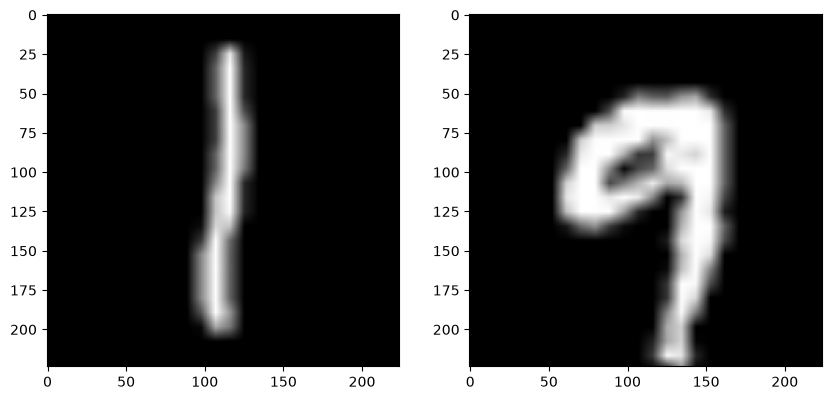

In [15]:
indexes = [np.random.randint(0,len(train_data)), np.random.randint(0,len(train_data))]

fig, axes = plt.subplots(1, 2, figsize=(10, 8))

axes[0].imshow(train_data[indexes[0]][0].numpy().transpose(1, 2, 0), cmap='gray')
axes[1].imshow(train_data[indexes[1]][0].numpy().transpose(1, 2, 0), cmap='gray')

plt.show()

In [16]:
# Carregar o modelo
vgg_16_model = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)

num_classes = 10
in_features = vgg_16_model.classifier[6].in_features

vgg_16_model.classifier[6] = torch.nn.Linear(in_features, num_classes)

new_first_conv = torch.nn.Conv2d(1, 64, kernel_size=3, padding=1)

vgg_16_model.features[0] = new_first_conv

In [17]:
vgg_16_model.eval()

test_loader = torch.utils.data.DataLoader(test_data, batch_size=1, shuffle=False, num_workers=1)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

print('device: '+ device)

vgg_16_model.to(device)

correct = 0

for batch_idx, (data, target) in enumerate(test_loader):
    data, target = data.to(device), target.to(device)
    output = vgg_16_model(data)
    if target == torch.argmax(torch.softmax(output, dim=1)):
        correct += 1

accuracy = correct / len(test_data)
print(f'Acuracia do modelo sem refinamento: {accuracy*100:.2f}%')

device: cuda
Acuracia do modelo sem refinamento: 13.00%


In [18]:
optimizer = torch.optim.SGD(vgg_16_model.parameters(), lr=0.0001)

loss_criterion = torch.nn.CrossEntropyLoss()

batch_size = 16
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=4)

epochs = 1

for epoch in range(epochs):
    vgg_16_model.train()

    vgg_16_model.to(device)

    train_loss = 0.0
    train_acc = 0.0
    valid_loss = 0.0
    valid_acc = 0.0

    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = vgg_16_model(inputs)
        loss = loss_criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)

        ret, predictions = torch.max(outputs.data, 1)
        correct_counts = predictions.eq(labels.data.view_as(predictions))

        acc = torch.mean(correct_counts.type(torch.FloatTensor))

        train_acc += acc.item() * inputs.size(0)
        print("Epoch: {}/{} | Batch: {}/{} | Loss: {:.4f} | Accuracy: {:.4f}".format(
            epoch + 1, epochs, batch_idx + 1, len(train_loader), loss.item(), acc.item()
        ))

Epoch: 1/1 | Batch: 1/3750 | Loss: 2.3196 | Accuracy: 0.0000
Epoch: 1/1 | Batch: 2/3750 | Loss: 2.3328 | Accuracy: 0.1250
Epoch: 1/1 | Batch: 3/3750 | Loss: 2.3640 | Accuracy: 0.0000
Epoch: 1/1 | Batch: 4/3750 | Loss: 2.4479 | Accuracy: 0.0000
Epoch: 1/1 | Batch: 5/3750 | Loss: 2.3743 | Accuracy: 0.1250
Epoch: 1/1 | Batch: 6/3750 | Loss: 2.3294 | Accuracy: 0.1875
Epoch: 1/1 | Batch: 7/3750 | Loss: 2.2898 | Accuracy: 0.1250
Epoch: 1/1 | Batch: 8/3750 | Loss: 2.3755 | Accuracy: 0.1250
Epoch: 1/1 | Batch: 9/3750 | Loss: 2.3257 | Accuracy: 0.1250
Epoch: 1/1 | Batch: 10/3750 | Loss: 2.3353 | Accuracy: 0.1250
Epoch: 1/1 | Batch: 11/3750 | Loss: 2.3979 | Accuracy: 0.0000
Epoch: 1/1 | Batch: 12/3750 | Loss: 2.2426 | Accuracy: 0.1875
Epoch: 1/1 | Batch: 13/3750 | Loss: 2.2011 | Accuracy: 0.1875
Epoch: 1/1 | Batch: 14/3750 | Loss: 2.3319 | Accuracy: 0.1250
Epoch: 1/1 | Batch: 15/3750 | Loss: 2.2755 | Accuracy: 0.1875
Epoch: 1/1 | Batch: 16/3750 | Loss: 2.2710 | Accuracy: 0.1250
Epoch: 1/1 | Batc

In [19]:
vgg_16_model.eval()

test_loader = torch.utils.data.DataLoader(test_data, batch_size=1, shuffle=False, num_workers=1)

correct = 0
for batch_idx, (data, target) in enumerate(test_loader):
    data, target = data.to(device), target.to(device)
    output = vgg_16_model(data)
    if target == torch.argmax(torch.softmax(output, dim=1)):
        correct += 1

print("Test Accuracy: {:.2f}%".format((correct / len(test_loader)) * 100))

Test Accuracy: 93.94%
